**Random Forest**

In [138]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

# Read CSV
df = pd.read_csv("data/dataset-merged-2.csv")
df=df.drop(columns=["Restaurant", "Terrasse"]) #prevent data leakage
display(df)

,Tag,Datum,Monat,is_fr_sa,Ferien-Value,Special-Day-Value,Niederschlag Tagessumme 6 UTC,Sonnenscheindauer Tagessumme,Lufttemperatur 2m Tagesmittel,Durchschnittliche Anzahl Geburtstage (über 100 Jahre),Tagesumsatz Restaurant
0,Fr,2021-01-01,Januar,1,1.0,1.0,0.6,0.0,1.7,6852.12,1620.2
1,Sa,2021-01-02,Januar,1,1.0,0.0,0.0,0.0,1.5,6852.12,872.9
2,So,2021-01-03,Januar,0,1.0,0.0,0.0,0.0,0.5,6852.12,0.0
3,Mo,2021-01-04,Januar,0,1.0,0.0,0.0,0.0,0.1,6852.12,636.2
4,Di,2021-01-05,Januar,0,1.0,0.0,0.0,0.0,-0.2,6852.12,694.5
...,...,...,...,...,...,...,...,...,...,...,...
1776,Mi,2025-11-12,November,0,0.0,0.0,0.0,419.0,6.2,6225.59,6642.5
1777,Do,2025-11-13,November,0,0.0,0.0,0.0,426.0,8.1,6225.59,7042.5
1778,Fr,2025-11-14,November,1,0.0,0.0,0.0,113.0,9.2,6225.59,12538.5
1779,Sa,2025-11-15,November,1,0.0,0.0,0.0,396.0,12.0,6225.59,17271.4


Train size (ohne Weihnachten/Silvester/Muttertag): (1433, 25)
Test size                                        : (306, 25)
MSE        : 9115211.66
RMSE       : 3019.14
R²         : 0.7567
MAE        : 2268.63
Relative MSE : 0.2906
MAPE         : 18.64%


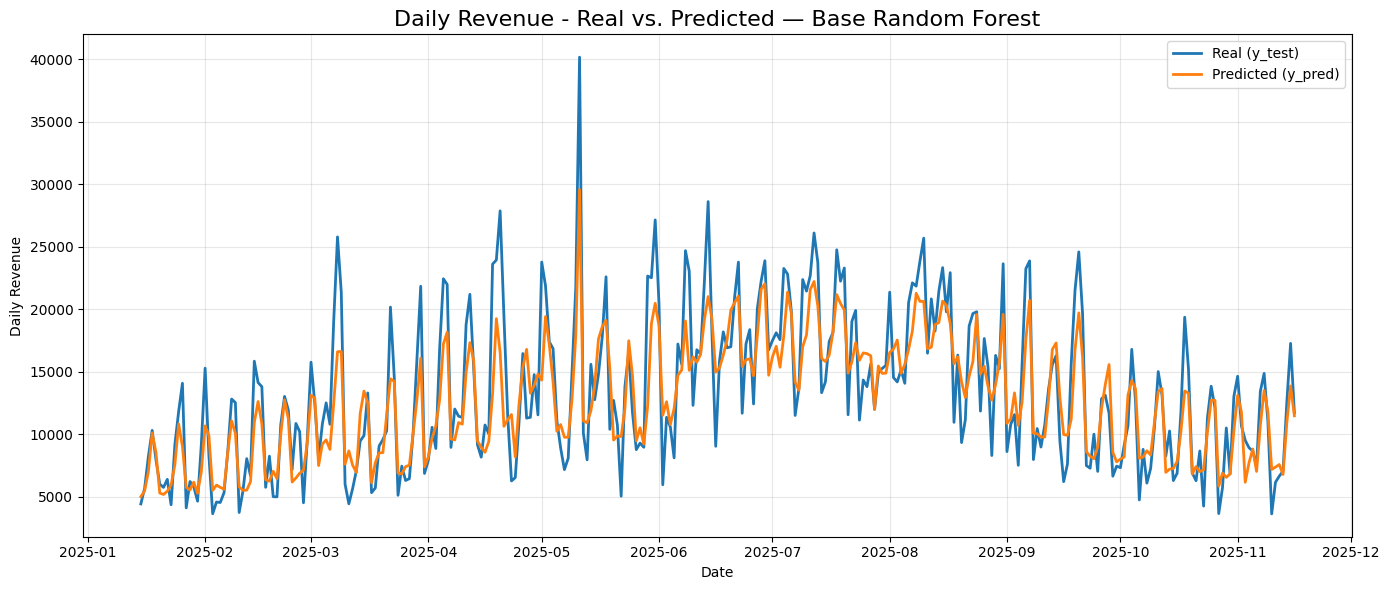

In [139]:
# Base Random Forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from helper_functions import is_christmas,is_mothers_day,is_special_day,mothers_day,is_silvester,holiday_average_last_3_years

# Convert and sort dates
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# Define target variable
target = "Tagesumsatz Restaurant"

# Create Lag-Features
df["lag1"] = df[target].shift(1)
df["lag2"] = df[target].shift(2)
df["lag3"] = df[target].shift(3)
df["lag7"] = df[target].shift(7)
df["lag14"] = df[target].shift(14)
df["lag21"] = df[target].shift(21)
df["lag28"] = df[target].shift(28)
df["lag30"] = df[target].shift(30)

# More date-related features
df["month"] = df["Datum"].dt.month
df["dayofyear"] = df["Datum"].dt.dayofyear
df["quarter"] = df["Datum"].dt.quarter
df["weekofyear"] = df["Datum"].dt.isocalendar().week.astype(int)
df["weekday"] = df["Datum"].dt.weekday

# Create Rolling Window features
df["roll_mean_7"] = df[target].shift(1).rolling(7).mean()
df["roll_mean_14"] = df[target].shift(1).rolling(14).mean()
df["roll_mean_28"] = df[target].shift(1).rolling(28).mean()

df["roll_std_7"] = df[target].shift(1).rolling(7).std()
df["roll_std_14"] = df[target].shift(1).rolling(14).std()

df = df.dropna().reset_index(drop=True)

# Choose features
num_cols = df.select_dtypes(include=["number"]).columns
feature_cols = [c for c in num_cols if c != target]

# Define featuers and target data
X = df[feature_cols]
y = df[target]

# Train-Test-Split
split_date = pd.Timestamp("2025-01-15")
train_mask = df["Datum"] < split_date
test_mask  = df["Datum"] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

train_dates = df.loc[train_mask, "Datum"]

# Exclude special days in training data as they are extreme outliers
special_mask_train = train_dates.apply(is_special_day)
X_train = X_train[~special_mask_train]
y_train = y_train[~special_mask_train]

print("Train size (ohne Weihnachten/Silvester/Muttertag):", X_train.shape)
print("Test size                                        :", X_test.shape)

# Standardizing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Random Forest Model
rf = RandomForestRegressor(
    n_estimators=300,      # number of trees in the forest; more trees = stabler but slower
    max_features="sqrt",   # number of features to consider when splitting each node ("sqrt" = square root of total)
    max_depth=15,          # limit on tree depth, prevents trees from growing too deep and overfitting
    min_samples_leaf=5,    # minimum number of samples required in a leaf node, larger = smoother predictions
    random_state=72        # seed for reproducibility, ensures the same results each time you run it
)

rf.fit(X_train, y_train)

# Compute the predictions on the training and test sets for logs data
y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf = rf.predict(X_test)

# Adjust for special days
y_pred_adjusted = y_pred_test_rf.copy()
test_dates = df.loc[test_mask, "Datum"].values
for i, d in enumerate(test_dates):
    d = pd.Timestamp(d)
    year = d.year

    if is_christmas(d):
        avg_xmas = holiday_average_last_3_years(
            df_full=df,
            date_func=lambda y_: pd.Timestamp(y_, 12, 24),
            year=year,
            target_col=target
        )
        if avg_xmas is not None:
            y_pred_adjusted[i] = avg_xmas

    if is_silvester(d):
        avg_silvester = holiday_average_last_3_years(
            df_full=df,
            date_func=lambda y_: pd.Timestamp(y_, 12, 31),
            year=year,
            target_col=target
        )
        if avg_silvester is not None:
            y_pred_adjusted[i] = avg_silvester

    if is_mothers_day(d):
        avg_mothers = holiday_average_last_3_years(
            df_full=df,
            date_func=mothers_day,
            year=year,
            target_col=target
        )
        if avg_mothers is not None:
            y_pred_adjusted[i] = avg_mothers



# Compute base metrics
mse = mean_squared_error(y_test, y_pred_adjusted)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_adjusted)
mae = mean_absolute_error(y_test, y_pred_adjusted)

# Compute relative MSE
y_naive = df.loc[test_mask, "lag1"].values
mse_model = mean_squared_error(y_test, y_pred_adjusted)
mse_naive = mean_squared_error(y_test, y_naive)
relative_MSE = mse_model / mse_naive

# Compute MAPE
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
mape_value = mape(y_test, y_pred_adjusted)

print(f"MSE        : {mse:.2f}")
print(f"RMSE       : {rmse:.2f}")
print(f"R²         : {r2:.4f}")
print(f"MAE        : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

# Plot the results
plt.figure(figsize=(14,6))
plt.plot(df.loc[test_mask, "Datum"], y_test, label="Real (y_test)", linewidth=2)
plt.plot(df.loc[test_mask, "Datum"], y_pred_adjusted, label="Predicted (y_pred)", linewidth=2)

plt.title("Daily Revenue - Real vs. Predicted — Base Random Forest", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Daily Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Boosted Random Forest**

MSE          : 7413408.52
RMSE         : 2722.76
R²           : 0.8021
MAE          : 2091.12
Relative MSE : 0.2364
MAPE         : 16.95%


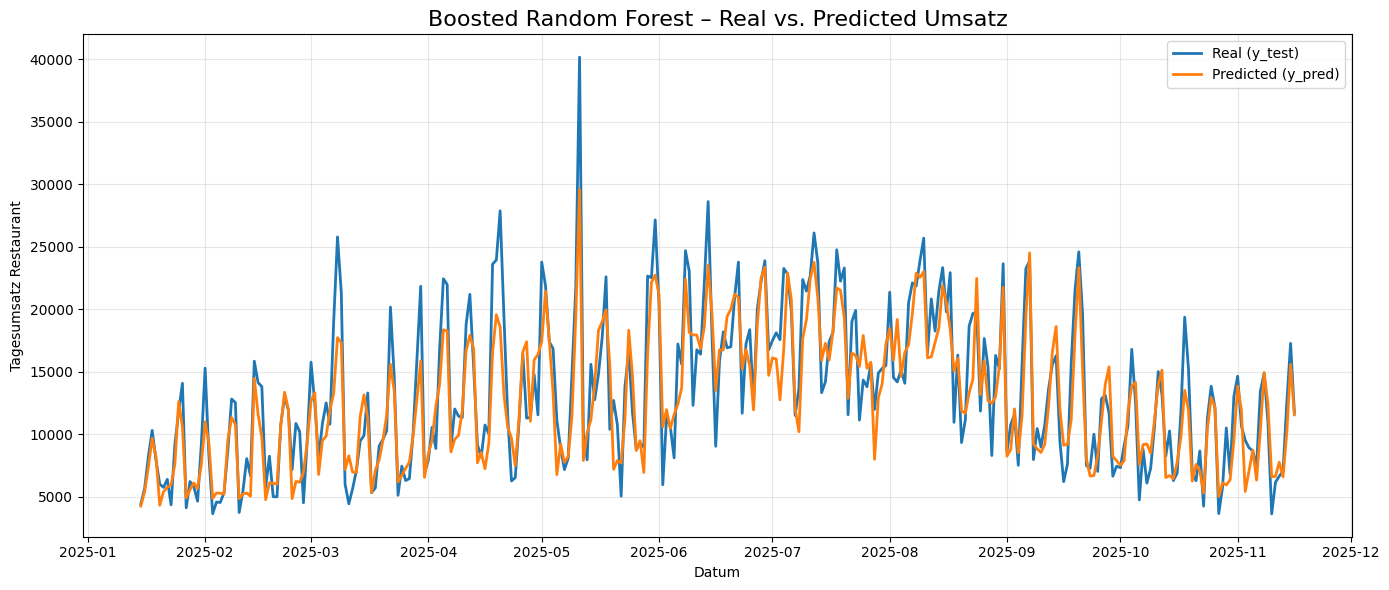

In [140]:
# Boosted Random Forest

from sklearn.ensemble import HistGradientBoostingRegressor

# Initialize boosted model
gb = HistGradientBoostingRegressor(
    learning_rate=0.05,       # how much each tree contributes to the final prediction (smaller = slower, safer learning)
    max_leaf_nodes=30,        # maximum number of leaves per tree, controls tree complexity
    min_samples_leaf=20,      # minimum samples per leaf, larger = more regularization and smoother model
    early_stopping=True,      # stop training early if validation score stops improving
    n_iter_no_change=20,      # number of rounds with no improvement before stopping
    validation_fraction=0.2,  # fraction of training data set aside internally for early stopping
    random_state=72,          # seed for reproducibility
    verbose=0                 # prints progress information while fitting (useful for teaching/demo)
)

gb.fit(X_train, y_train)

# Compute the predictions on the training and test sets for logs data
y_pred_train_gb = gb.predict(X_train)
y_pred_test_gb = gb.predict(X_test)

# Adjust for special days
y_pred_adjusted = y_pred_test_gb.copy()
test_dates = df.loc[test_mask, "Datum"].values
for i, d in enumerate(test_dates):
    d = pd.Timestamp(d)
    year = d.year

    if is_christmas(d):
        avg_xmas = holiday_average_last_3_years(
            df_full=df,
            date_func=lambda y_: pd.Timestamp(y_, 12, 24),
            year=year,
            target_col=target
        )
        if avg_xmas is not None:
            y_pred_adjusted[i] = avg_xmas

    if is_silvester(d):
        avg_silvester = holiday_average_last_3_years(
            df_full=df,
            date_func=lambda y_: pd.Timestamp(y_, 12, 31),
            year=year,
            target_col=target
        )
        if avg_silvester is not None:
            y_pred_adjusted[i] = avg_silvester

    if is_mothers_day(d):
        avg_mothers = holiday_average_last_3_years(
            df_full=df,
            date_func=mothers_day,
            year=year,
            target_col=target
        )
        if avg_mothers is not None:
            y_pred_adjusted[i] = avg_mothers


# Compute base metrics on test-set
mse = mean_squared_error(y_test, y_pred_adjusted)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_adjusted)
mae = mean_absolute_error(y_test, y_pred_adjusted)

# Compute relative MSE
y_naive = df.loc[test_mask, "lag1"].values
mse_model = mean_squared_error(y_test, y_pred_adjusted)
mse_naive = mean_squared_error(y_test, y_naive)
relative_MSE = mse_model / mse_naive

# Compute MAPE
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
mape_value = mape(y_test, y_pred_adjusted)

# Print block
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")


# Plot the results
plt.figure(figsize=(14,6))
plt.plot(df.loc[test_mask, "Datum"], y_test, label="Real (y_test)", linewidth=2)
plt.plot(df.loc[test_mask, "Datum"], y_pred_adjusted, label="Predicted (y_pred)", linewidth=2)

plt.title("Boosted Random Forest – Real vs. Predicted Umsatz", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [141]:
# Helper Class for specially designed CrossValidator suited for 7-day forecast

from sklearn.model_selection import BaseCrossValidator

# Separate class for cross-validation
class SevenDayForecastCV(BaseCrossValidator):
    """
    Expanding-window time-series CV splitter
    where each test set is exactly `horizon` steps long.
    """

    def __init__(self, n_splits=5, horizon=7):
        self.n_splits = n_splits
        self.horizon = horizon

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        horizon = self.horizon

        # training end points — equally spaced
        split_points = np.linspace(
            start=horizon,
            stop=n_samples - horizon,
            num=self.n_splits + 1,
            dtype=int
        )[1:]

        for train_end in split_points:
            train_idx = np.arange(train_end)
            test_idx = np.arange(train_end, train_end + horizon)
            yield train_idx, test_idx

**Hyperparameter Tuned Random Forest using Custom Cross-Validation**

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_samples': 0.9, 'max_features': 1.0, 'max_depth': 20}
Best CV MSE: 13011225.470355567
Fold 1
 Train: 0 → 289 length: 290
 Test : 290 → 296 length: 7

Fold 2
 Train: 0 → 573 length: 574
 Test : 574 → 580 length: 7

Fold 3
 Train: 0 → 857 length: 858
 Test : 858 → 864 length: 7

Fold 4
 Train: 0 → 1141 length: 1142
 Test : 1142 → 1148 length: 7

Fold 5
 Train: 0 → 1425 length: 1426
 Test : 1426 → 1432 length: 7

MSE          : 7397489.90
RMSE         : 2719.83
R²           : 0.8025
MAE          : 2084.74
Relative MSE : 0.2359
MAPE         : 16.88%


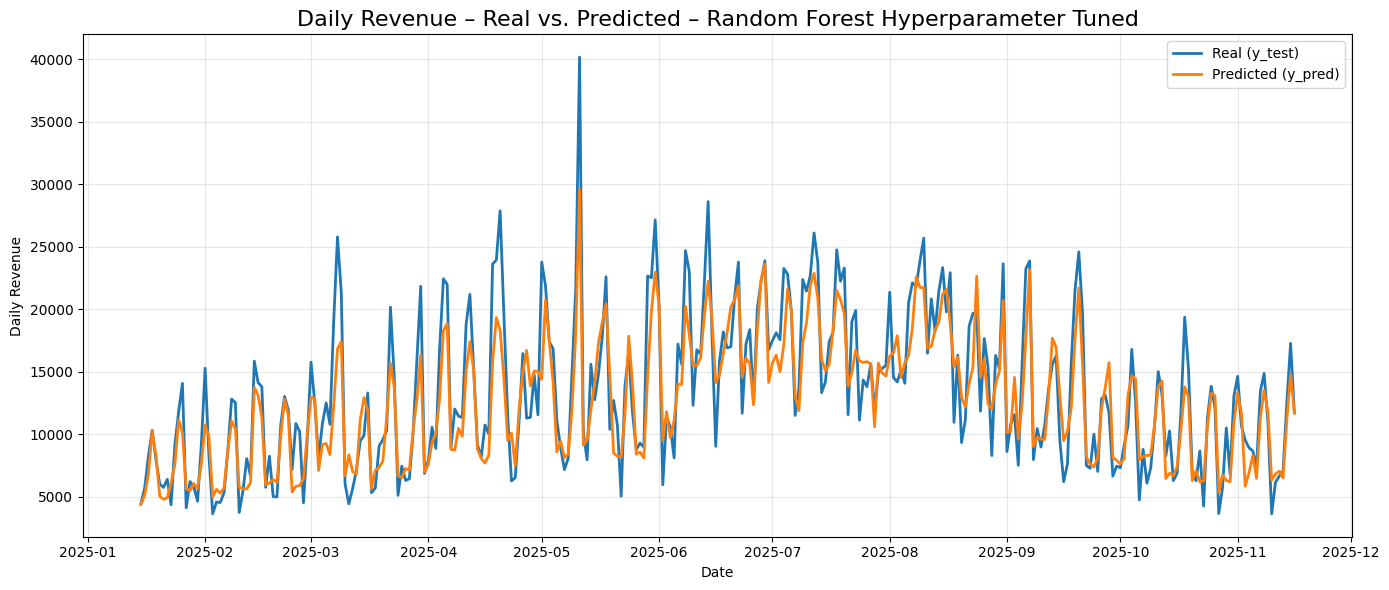

In [142]:
# Hyperparameter Tuned Random Forest
from sklearn.model_selection import ParameterSampler
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# Parameter grid for Random Forest
param_distributions = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [10, 20, 30, 40, None],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
    "max_samples": [None, 0.7, 0.8, 0.9]
}

# Time series cross-validation
cv = SevenDayForecastCV(n_splits=5, horizon=7)

# Randomized search
search = RandomizedSearchCV(
    estimator=RandomForestRegressor(bootstrap=True),
    param_distributions=param_distributions,
    n_iter=24,
    scoring="neg_mean_squared_error",
    cv=cv,
    random_state=72,
    refit=True,
    verbose=1,
    return_train_score=False
)

# Fit search only on training data
search.fit(X_train, y_train)
print("\nBest Params:", search.best_params_)
print("Best CV MSE:", -search.best_score_)

# Best model after tuning
best_model = search.best_estimator_
y_pred_test = best_model.predict(X_test)

# Adjust for special days
y_pred_adjusted = y_pred_test.copy()
test_dates = df.loc[test_mask, "Datum"].values
for i, d in enumerate(test_dates):
    d = pd.Timestamp(d)
    year = d.year

    if is_christmas(d):
        avg_xmas = holiday_average_last_3_years(
            df_full=df,
            date_func=lambda y_: pd.Timestamp(y_, 12, 24),
            year=year,
            target_col=target
        )
        if avg_xmas is not None:
            y_pred_adjusted[i] = avg_xmas

    if is_silvester(d):
        avg_silvester = holiday_average_last_3_years(
            df_full=df,
            date_func=lambda y_: pd.Timestamp(y_, 12, 31),
            year=year,
            target_col=target
        )
        if avg_silvester is not None:
            y_pred_adjusted[i] = avg_silvester

    if is_mothers_day(d):
        avg_mothers = holiday_average_last_3_years(
            df_full=df,
            date_func=mothers_day,
            year=year,
            target_col=target
        )
        if avg_mothers is not None:
            y_pred_adjusted[i] = avg_mothers

# Compute basic metrics
mse = mean_squared_error(y_test, y_pred_adjusted)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_adjusted)
mae = mean_absolute_error(y_test, y_pred_adjusted)

# Compute relative MSE
y_naive = df.loc[test_mask, "lag1"].values
mse_naive = mean_squared_error(y_test, y_naive)
relative_MSE = mse / mse_naive

# Compute MAPE
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
mape_value = mape(y_test, y_pred_adjusted)

# Display individual fold results
for fold, (train_idx, test_idx) in enumerate(cv.split(X_train)):
    print(f"Fold {fold+1}")
    print(" Train:", train_idx[0], "→", train_idx[-1], "length:", len(train_idx))
    print(" Test :", test_idx[0], "→", test_idx[-1], "length:", len(test_idx))
    print()

# Display final metrics
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")


# Plot the results
plt.figure(figsize=(14,6))
plt.plot(df.loc[test_mask, "Datum"], y_test, label="Real (y_test)", linewidth=2)
plt.plot(df.loc[test_mask, "Datum"], y_pred_adjusted, label="Predicted (y_pred)", linewidth=2)
plt.title("Daily Revenue – Real vs. Predicted – Random Forest Hyperparameter Tuned", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Daily Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Boosted Random Forest combining Scaler-Pipeline, more aggressive parameters and custom Cross-Validation**

Fitting 7 folds for each of 20 candidates, totalling 140 fits

Best Params: {'model__min_samples_leaf': 20, 'model__max_leaf_nodes': 15, 'model__max_depth': 5, 'model__max_bins': 128, 'model__learning_rate': 0.02, 'model__l2_regularization': 0.5}
Best CV MSE: 0.053830840413941365
Fold 1
 Train: 0 → 208 length: 209
 Test : 209 → 215 length: 7

Fold 2
 Train: 0 → 411 length: 412
 Test : 412 → 418 length: 7

Fold 3
 Train: 0 → 614 length: 615
 Test : 615 → 621 length: 7

Fold 4
 Train: 0 → 816 length: 817
 Test : 817 → 823 length: 7

Fold 5
 Train: 0 → 1019 length: 1020
 Test : 1020 → 1026 length: 7

Fold 6
 Train: 0 → 1222 length: 1223
 Test : 1223 → 1229 length: 7

Fold 7
 Train: 0 → 1425 length: 1426
 Test : 1426 → 1432 length: 7

MSE          : 6285672.40
RMSE         : 2507.12
R²           : 0.8322
MAE          : 1953.02
Relative MSE : 0.2004
MAPE         : 16.61%


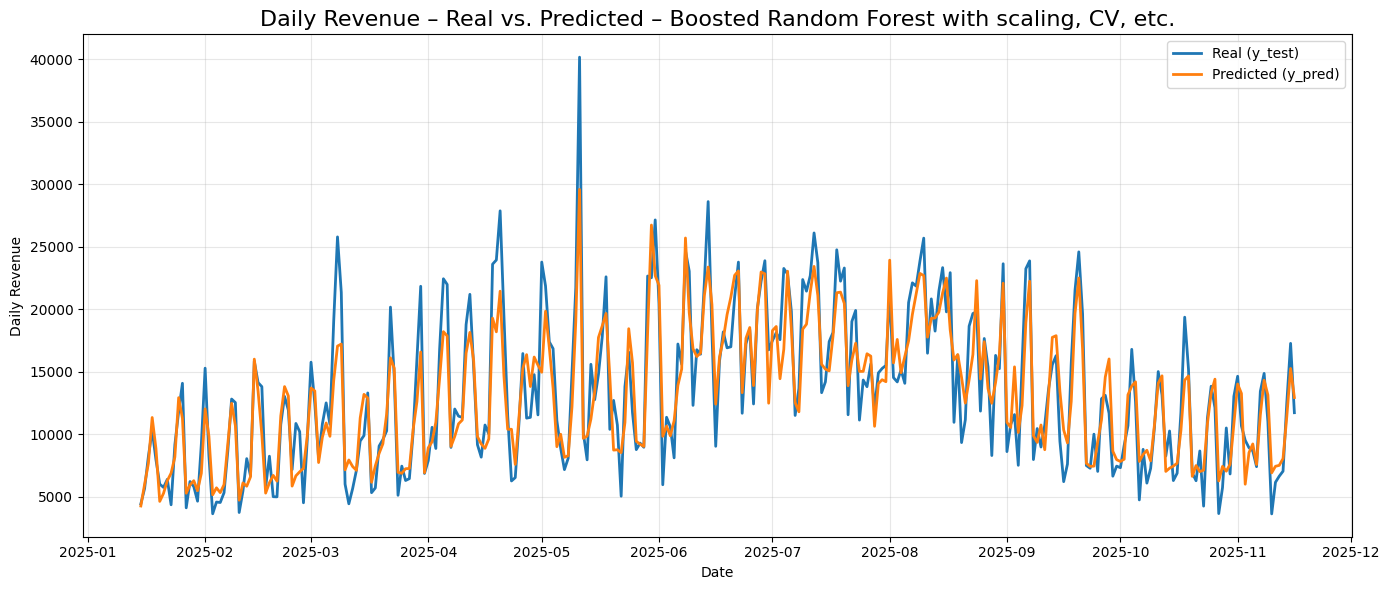

In [143]:
# Model combining Boosting, Scaler-Pipeline, more agressive parameters, etc.

from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import HistGradientBoostingRegressor

# Initializing Boosting Regressor
gb = HistGradientBoostingRegressor(
    loss="squared_error",
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    max_iter=200,
    random_state=72
)

# Initializing pipeline with model and scaler
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", gb)
])

param_distributions = {
    "model__learning_rate": [0.005, 0.01, 0.02],
    "model__max_depth": [3, 4, 5],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 30, 50],
    "model__l2_regularization": [0.0, 0.1, 0.5],
    "model__max_bins": [64, 128, 255],
}


# Time series cross-validation
cv = SevenDayForecastCV(n_splits=7, horizon=7)

# Randomized search
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_mean_squared_error",
    cv=cv,
    random_state=72,
    refit=True,
    verbose=1,
)

# Map training targets logarithmically
y_train_log = np.log1p(y_train)

# Fit search only on training data
search.fit(X_train, y_train_log)
print("\nBest Params:", search.best_params_)
print("Best CV MSE:", -search.best_score_)

# Best model after tuning
best_model = search.best_estimator_
y_pred_log = best_model.predict(X_test)

# Bias correction
train_preds = best_model.predict(X_train)
sigma2 = np.var(y_train_log - train_preds)

y_pred_test = np.exp(y_pred_log + 0.5 * sigma2) - 1
y_pred_test = np.clip(y_pred_test, 0, None)

# Adjust for special days
y_pred_adjusted = y_pred_test.copy()
test_dates = df.loc[test_mask, "Datum"].values
for i, d in enumerate(test_dates):
    d = pd.Timestamp(d)
    year = d.year

    if is_christmas(d):
        avg_xmas = holiday_average_last_3_years(
            df_full=df,
            date_func=lambda y_: pd.Timestamp(y_, 12, 24),
            year=year,
            target_col=target
        )
        if avg_xmas is not None and (abs(y_pred_adjusted[i] - avg_xmas) > 100):
            y_pred_adjusted[i] = avg_xmas

    if is_silvester(d):
        avg_silvester = holiday_average_last_3_years(
            df_full=df,
            date_func=lambda y_: pd.Timestamp(y_, 12, 31),
            year=year,
            target_col=target
        )
        if avg_silvester is not None and (abs(y_pred_adjusted[i] - avg_xmas) > 100):
            y_pred_adjusted[i] = avg_silvester

    if is_mothers_day(d):
        avg_mothers = holiday_average_last_3_years(
            df_full=df,
            date_func=mothers_day,
            year=year,
            target_col=target
        )
        if avg_mothers is not None and (abs(y_pred_adjusted[i] - avg_xmas) > 100):
            y_pred_adjusted[i] = avg_mothers

# Compute basic metrics
mse = mean_squared_error(y_test, y_pred_adjusted)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_adjusted)
mae = mean_absolute_error(y_test, y_pred_adjusted)

# Compute relative MSE
y_naive = df.loc[test_mask, "lag1"].values
mse_naive = mean_squared_error(y_test, y_naive)
relative_MSE = mse / mse_naive

# Compute MAPE
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
mape_value = mape(y_test, y_pred_adjusted)

# Display individual fold results
for fold, (train_idx, test_idx) in enumerate(cv.split(X_train)):
    print(f"Fold {fold+1}")
    print(" Train:", train_idx[0], "→", train_idx[-1], "length:", len(train_idx))
    print(" Test :", test_idx[0], "→", test_idx[-1], "length:", len(test_idx))
    print()

# Display final metrics
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")


# Plot the results
plt.figure(figsize=(14,6))
plt.plot(df.loc[test_mask, "Datum"], y_test, label="Real (y_test)", linewidth=2)
plt.plot(df.loc[test_mask, "Datum"], y_pred_adjusted, label="Predicted (y_pred)", linewidth=2)

plt.title("Daily Revenue – Real vs. Predicted – Boosted Random Forest with scaling, CV, etc.", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Daily Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()